# About Dataset

The New York City Taxi and Limousine Commission (TLC), created in 1971, is the agency responsible for licensing and regulating New York City Medallion (Yellow) taxi cabs, for-hire vehicles (community-based liveries, black cars and luxury limousines), commuter vans, and paratransit vehicles. 
Over 200,000 TLC licensees complete approximately 1,000,000 trips each day. To operate for hire, drivers must first undergo a background check, have a safe driving record, and complete 24 hours of driver training. TLC-licensed vehicles are inspected for safety and emissions at TLC Woodside Inspection Facility.

In partnership with the New York City Department of Information Technology and Telecommunications (DOITT), TLC has published millions of trip records from both yellow medallion taxis and green SHLs.

# Importing necessary libraries

In [2]:
import pandas as pd
import numpy as np

# Loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Reading parquet file from drive and coverting it to Dataframe

In [4]:
df = pd.read_parquet('/content/drive/MyDrive/NYC dataset/merged_6_months_yellow_taxi_2025.parquet')

# Viewing 10 random rows of the dataset

In [69]:
df.sample(10)

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
18313727,2,2025-05-21 11:22:51,2025-05-21 11:27:02,2.0,0.51,1.0,N,246,246,1,5.80,0.00,0.5,2.109375,0.0,1.0,12.660000,2.5,0.0,0.75
14903216,2,2025-06-04 08:45:05,2025-06-04 08:58:14,NaN,1.46,NaN,None,114,13,0,11.14,0.00,0.5,0.000000,0.0,1.0,15.890000,NaN,NaN,0.75
9684649,2,2025-03-21 13:45:34,2025-03-21 13:52:38,1.0,0.81,1.0,N,262,236,1,7.90,0.00,0.5,1.190430,0.0,1.0,13.090000,2.5,0.0,0.00
20120940,2,2025-05-18 15:00:18,2025-05-18 15:14:44,NaN,0.94,NaN,None,186,230,0,15.68,0.00,0.5,4.089844,0.0,1.0,24.520000,NaN,NaN,0.75
23985568,2,2025-01-26 22:30:14,2025-01-26 22:41:26,NaN,2.70,NaN,None,229,263,0,12.74,0.00,0.5,0.000000,0.0,1.0,17.490000,NaN,NaN,0.75
23401830,1,2025-01-30 18:08:10,2025-01-30 18:23:46,1.0,2.40,1.0,N,142,166,1,14.20,5.00,0.5,5.199219,0.0,1.0,25.900000,2.5,0.0,0.00
12602321,2,2025-06-09 17:18:00,2025-06-09 17:33:31,1.0,3.58,1.0,N,170,148,1,18.40,2.50,0.5,5.128906,0.0,1.0,30.780001,2.5,0.0,0.75
4830347,1,2025-04-12 12:06:39,2025-04-12 12:20:07,1.0,2.20,1.0,N,161,236,1,14.90,3.25,0.5,3.900391,0.0,1.0,23.549999,2.5,0.0,0.75
16425750,1,2025-05-04 14:11:04,2025-05-04 14:28:57,2.0,1.80,1.0,N,237,230,1,15.60,3.25,0.5,4.050781,0.0,1.0,24.400000,2.5,0.0,0.75
14976274,2,2025-06-05 21:51:58,2025-06-05 22:07:01,NaN,2.05,NaN,None,144,87,0,-4.75,0.00,0.5,0.000000,0.0,1.0,4.920000,NaN,NaN,0.75


## Overview of the dataset

In [5]:
df.shape

(24083384, 20)

This dataset has 24083384 rows and 20 columns

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24083384 entries, 0 to 24083383
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               uint16        
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float16       
 4   trip_distance          float32       
 5   RatecodeID             float16       
 6   store_and_fwd_flag     object        
 7   PULocationID           uint16        
 8   DOLocationID           uint16        
 9   payment_type           uint16        
 10  fare_amount            float32       
 11  extra                  float16       
 12  mta_tax                float16       
 13  tip_amount             float16       
 14  tolls_amount           float16       
 15  improvement_surcharge  float16       
 16  total_amount           float32       
 17  congestion_surcharge   float16       
 18  Airport_fee         

The datatypes of this dataset are: datetime64[us](2), float16(10), float32(3), object(1), uint16(4)

Memory usage: 1.4+ GB

# Checking if my dataset has any duplicates or not, if present then drop those columns

In [ ]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows}")

# Checking for null values

In [ ]:
df.isnull().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,5418601
trip_distance,0
RatecodeID,5418601
store_and_fwd_flag,5418601
PULocationID,0
DOLocationID,0
payment_type,0


Only these specific columns has nul values:
    
passenger_count: 5418601
, RatecodeID: 5418601
, store_and_fwd_flag: 5418601	
, congestion_surcharge: 5418601
, Airport_fee: 5418601

# Defining a general outlier detection func

In [7]:
def detect_outliers(df, col):
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  return outliers[col]

# Data Cleaning

### Next we will check each and every features one by one and clean it.

### Col = VendorID, A code indicating the TPEP provider that provided the record.  
1 = Creative Mobile Technologies, LLC
2 = Curb Mobility, LLC
6 = Myle Technologies Inc
7 = Helix

Step 1: Since this is a categorical column, we start by checking the unique values present in this column

In [8]:
df['VendorID'].unique()

array([2, 1, 7, 6], dtype=uint16)

This column had no null values, this column is cleaned

### Col = tpep_pickup_datetime, tpep_dropoff_datetime, checking if the durations are valid or not.

Step 1: Checking if some rows has negative time duration or not

In [9]:
from datetime import timedelta
(df['tpep_dropoff_datetime']-df['tpep_pickup_datetime'] < timedelta(0)).sum()

np.int64(793)

Step 2: 793 values has negative duration which is not possible so, lets inspect those cols

In [10]:
df[df['tpep_dropoff_datetime']-df['tpep_pickup_datetime'] < timedelta(0)]

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
47146,1,2025-02-01 14:45:00,2025-02-01 13:49:59,1.0,3.40,99.0,N,67,155,1,23.5,0.0,0.5,0.0,0.000000,0.000000,24.000000,0.0,0.0,0.0
274370,1,2025-02-03 20:00:00,2025-02-03 18:42:16,1.0,10.70,99.0,N,167,76,1,50.5,0.0,0.5,0.0,0.000000,0.000000,51.000000,0.0,0.0,0.0
320001,1,2025-02-04 13:00:00,2025-02-04 12:44:50,1.0,1.20,99.0,N,89,188,1,18.5,0.0,0.5,0.0,0.000000,0.000000,19.000000,0.0,0.0,0.0
586818,1,2025-02-06 21:30:00,2025-02-06 20:45:32,1.0,7.60,99.0,N,188,95,1,38.5,0.0,0.5,0.0,0.000000,0.000000,39.000000,0.0,0.0,0.0
699703,1,2025-02-07 22:00:00,2025-02-07 21:59:00,1.0,10.50,99.0,N,231,169,1,44.5,0.0,0.5,0.0,0.000000,0.000000,45.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24027361,6,2025-01-29 22:01:23,2025-01-29 22:01:13,NaN,4.92,NaN,None,61,76,0,2.9,0.0,0.5,0.0,0.000000,0.300049,22.639999,NaN,NaN,0.0
24033084,6,2025-01-30 08:01:40,2025-01-30 08:01:09,NaN,13.77,NaN,None,146,175,0,2.9,0.0,0.5,0.0,0.000000,0.300049,44.720001,NaN,NaN,0.0
24038863,6,2025-01-30 16:01:38,2025-01-30 16:01:31,NaN,5.18,NaN,None,142,42,0,2.9,0.0,0.5,0.0,0.000000,0.300049,27.809999,NaN,NaN,0.0
24051998,6,2025-01-30 23:01:38,2025-01-30 23:01:26,NaN,7.30,NaN,None,183,119,0,2.9,0.0,0.5,0.0,0.000000,0.300049,24.200001,NaN,NaN,0.0


Step 3: from the above data, pickupdate has later date whereas dropoff date has previous date values that's why the duration is coming to be negative, so swapping the values.

In [11]:
# Identify rows where pickup_datetime is after dropoff_datetime
invalid_duration_mask = df['tpep_pickup_datetime'] > df['tpep_dropoff_datetime']

# For these rows, swap the pickup and dropoff times
df.loc[invalid_duration_mask, ['tpep_pickup_datetime', 'tpep_dropoff_datetime']] = \
    df.loc[invalid_duration_mask, ['tpep_dropoff_datetime', 'tpep_pickup_datetime']].values

# Verify that there are no more negative durations
negative_durations_after_swap = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime'] < timedelta(0)).sum()
print(f"Number of negative durations after swapping: {negative_durations_after_swap}")

Number of negative durations after swapping: 0


These two columns has been correctly handled with no data errors

### Col = passenger_count

Step 1: Since this is a numerical column, bringing up the descriptive statistics

In [12]:
df['passenger_count'].describe()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)


,passenger_count
count,18664783.0
mean,NaN
std,0.0
min,0.0
25%,1.0
50%,1.0
75%,1.0
max,9.0


Step 2: Checking for unique values present in this column

df['passenger_count'].unique()

passenger count <=1 and >=6 is invalid data

Step 3: Checking value counts

In [14]:
df['passenger_count'].value_counts(dropna=False)

,count
passenger_count,
1.0,14801266
NaN,5418601
2.0,2583182
3.0,590567
4.0,385702
0.0,138981
5.0,104556
6.0,60445
8.0,52


Step 4: Detecting outliers

In [2]:
# detecting outliers from passenger_count col

detect_outliers(df, 'passenger_count')

NameError: name 'detect_outliers' is not defined

Step 5: Handling `passenger_count` outliers and nulls

Based on our observations, `passenger_count` has `NaN` values, `0` values (which are illogical for a taxi trip), and some extreme values greater than 6. We will apply the following strategy:

1.  **Impute `NaN` values:** Replace `NaN` with the mode of `passenger_count` (which is 1).
2.  **Handle `0` values:** Replace `0` with `1` (as a taxi trip must have at least one passenger).
3.  **Handle `>6` values:** Replace values greater than 6 with the median of the `passenger_count` (excluding 0s and nulls) to mitigate their impact as outliers.

In [16]:
# Get the mode of passenger_count (which is 1.0 based on previous value_counts)
passenger_count_mode = df['passenger_count'].mode()[0]

# Impute NaN values with the mode (1.0)
df['passenger_count'].fillna(passenger_count_mode, inplace=True)

# Replace 0 passenger counts with the mode (1.0)
df.loc[df['passenger_count'] == 0, 'passenger_count'] = passenger_count_mode

# Calculate the median of valid passenger counts (excluding 0 and NaN) for capping outliers > 6
# First, ensure we're not including the 0s we just replaced or any remaining NaNs (though fillna should handle them)
valid_passenger_counts = df['passenger_count'][(df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]
passenger_count_median = valid_passenger_counts.median()

# Replace passenger counts > 6 with the median
df.loc[df['passenger_count'] > 6, 'passenger_count'] = passenger_count_median

print(f"Passenger count mode used for imputation and 0 replacement: {passenger_count_mode}")
print(f"Passenger count median used for capping >6 outliers: {passenger_count_median}")

# Verify the changes
print("\nPassenger count after cleaning:")
print(df['passenger_count'].value_counts(dropna=False))

/tmp/ipykernel_95314/3784244842.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['passenger_count'].fillna(passenger_count_mode, inplace=True)


Passenger count mode used for imputation and 0 replacement: 1.0
Passenger count median used for capping >6 outliers: 1.0

Passenger count after cleaning:
passenger_count
1.0    20358932
2.0     2583182
3.0      590567
4.0      385702
5.0      104556
6.0       60445
Name: count, dtype: int64


This column has been cleaned.

### Col = trip_distance

Step 1: Numerical column, descriptive statistics

In [17]:
df['trip_distance'].describe()

,trip_distance
count,2.408338e+07
mean,6.828008e+00
std,6.305496e+02
min,0.000000e+00
25%,1.020000e+00
50%,1.800000e+00
75%,3.490000e+00
max,3.860884e+05


Step 2: Checking skewness

In [18]:

df['trip_distance'].skew()

np.float32(234.83302)

The trip_distance data is not symmetrically distributed. Most trips cover short distances.
The mean trip_distance will be greater than the median trip_distance because the larger, outlying trip distances pull the mean upwards.
This often suggests the presence of outliers on the higher end.

Step 3: Checking unique values

In [19]:
import numpy as np
np.sort(df['trip_distance'].unique())

array([0.0000000e+00, 9.9999998e-03, 2.0000000e-02, ..., 3.2013628e+05,
       3.3578369e+05, 3.8608844e+05], dtype=float32)

Step 4: Before proceeding with other things, first let's check for distance=0 and fare amount

In [20]:
#df[df['trip_distance'] == 0]['fare_amount']
zero_distance=(df['trip_distance'] == 0).sum()

In [21]:
pct_zeros = (zero_distance / df.shape[0]) * 100
print(f"Percentage of rows with trip_distance = 0: {pct_zeros:.2f}%")

Percentage of rows with trip_distance = 0: 2.75%


Step 5: Handling illogical `trip_distance` and `fare_amount`

We observed rows where `trip_distance` is 0 but `fare_amount` is not 0, and also cases where `fare_amount` is negative. These are highly illogical for a taxi trip and likely represent data errors and since the percentages of these values is less than 5% We will remove these rows to ensure data quality.

In [22]:
# Count rows where trip_distance is 0 but fare_amount is not 0
zero_distance_non_zero_fare = df[(df['trip_distance'] == 0) & (df['fare_amount'] != 0)].shape[0]
print(f"Number of rows with 0 trip_distance and non-zero fare_amount: {zero_distance_non_zero_fare}")

# Count rows where fare_amount is negative
negative_fare_amount = df[df['fare_amount'] < 0].shape[0]
print(f"Number of rows with negative fare_amount: {negative_fare_amount}")

# Filter out these problematic rows
initial_rows = df.shape[0]
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] != 0))]
df = df[df['fare_amount'] >= 0] # Also remove any remaining negative fare amounts (if not already covered)

print(f"\nInitial number of rows: {initial_rows}")
print(f"Number of rows after cleaning: {df.shape[0]}")
print(f"Number of rows removed: {initial_rows - df.shape[0]}")

Number of rows with 0 trip_distance and non-zero fare_amount: 657758
Number of rows with negative fare_amount: 1323048

Initial number of rows: 24083384
Number of rows after cleaning: 22220880
Number of rows removed: 1862504


Step 6: Handling outliers

In [23]:
# now we will handle distance outliers
df['trip_distance'].value_counts(dropna=False)

,count
trip_distance,
0.900000,261318
1.000000,260061
0.800000,256069
1.100000,253416
1.200000,246381
...,...
4949.310059,1
61.599998,1
202771.625000,1


In [24]:
trip_distance_outliers = detect_outliers(df, 'trip_distance')
print(f"Number of trip_distance outliers detected: {len(trip_distance_outliers)}")
print("Top 100 trip_distance outlier values:")
print(trip_distance_outliers.nlargest(100))

Number of trip_distance outliers detected: 2690301
Top 100 trip_distance outlier values:
7400424     386088.437500
6837615     335783.687500
6986512     302622.500000
7321530     285554.625000
11524548    281085.562500
                ...      
15546863    131469.890625
15215084    131010.742188
20214293    130913.351562
19888692    129410.171875
20574902    129018.843750
Name: trip_distance, Length: 100, dtype: float32


The detected outliers show some extremely large `trip_distance` values, some of which are hundreds of thousands of miles. This is highly unlikely for a single taxi trip within NYC. Let's inspect the rows corresponding to these most extreme distances, focusing on their `PULocationID` and `DOLocationID`.

In [25]:
extreme_distance_rows = df[df['trip_distance'].isin(trip_distance_outliers.nlargest(10).values)]
display(extreme_distance_rows[['trip_distance', 'PULocationID', 'DOLocationID']])

,trip_distance,PULocationID,DOLocationID
6837615,335783.687500,158,68
6986512,302622.500000,239,144
7260740,260485.796875,148,75
7321530,285554.625000,129,79
7400424,386088.437500,236,230
11406442,280125.562500,215,258
11524548,281085.562500,215,130
14901869,261262.390625,79,164
19729422,263103.968750,148,249
23796659,276099.937500,224,233


Step 7: Removing extreme distance outliers

In [26]:
# Remove the extreme trip_distance outliers
initial_rows_before_distance_outlier_removal = df.shape[0]

Q1_dist = df['trip_distance'].quantile(0.25)
Q3_dist = df['trip_distance'].quantile(0.75)
IQR_dist = Q3_dist - Q1_dist
upper_bound_dist = Q3_dist + 1.5 * IQR_dist

df = df[df['trip_distance'] <= upper_bound_dist]

print(f"Number of rows before removing trip_distance outliers: {initial_rows_before_distance_outlier_removal}")
print(f"Number of rows after removing trip_distance outliers: {df.shape[0]}")
print(f"Number of trip_distance outliers removed: {initial_rows_before_distance_outlier_removal - df.shape[0]}")


Number of rows before removing trip_distance outliers: 22220880
Number of rows after removing trip_distance outliers: 19530579
Number of trip_distance outliers removed: 2690301


With these extreme distance outliers handled, our `trip_distance` column should now be more realistic for NYC taxi operations. We have removed trips that were clearly impossible, which will improve the reliability of any models or further analyses we perform.

In [27]:
df.isnull().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,3701558
store_and_fwd_flag,3701558
PULocationID,0
DOLocationID,0
payment_type,0


### Col = RateCodeID, The final rate code in effect at the end of the trip.
1 = Standard rate
2 = JFK
3 = Newark
4 = Nassau or Westchester
5 = Negotiated fare
6 = Group ride
99 = Null/unknown

Step 1: Categorical column, value counts

In [28]:
print(df['RatecodeID'].value_counts(dropna=False))

RatecodeID
1.0     15626559
NaN      3701558
99.0      120086
5.0        55526
2.0        15626
3.0         7905
4.0         3307
6.0           12
Name: count, dtype: int64


Step 2: Imputing null and 99 values with the mode

In [29]:
# Calculate the mode for RatecodeID, excluding NaNs and 99.0 temporarily
ratecode_mode = df[~df['RatecodeID'].isin([99.0])]['RatecodeID'].mode()[0]

# Replace 99.0 with NaN first, then fill all NaNs with the mode
df['RatecodeID'].replace(99.0, np.nan, inplace=True)
df['RatecodeID'].fillna(ratecode_mode, inplace=True)

print(f"RatecodeID mode used for imputation: {ratecode_mode}")
print("\nRatecodeID distribution after cleaning:")
print(df['RatecodeID'].value_counts(dropna=False))

/tmp/ipykernel_95314/3160630507.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['RatecodeID'].replace(99.0, np.nan, inplace=True)
/tmp/ipykernel_95314/3160630507.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

RatecodeID mode used for imputation: 1.0

RatecodeID distribution after cleaning:
RatecodeID
1.0    19448203
5.0       55526
2.0       15626
3.0        7905
4.0        3307
6.0          12
Name: count, dtype: int64


Now that the `RatecodeID` column has been cleaned by imputing missing and 'unknown' values with the mode, it's ready for further analysis. We've ensured that all `RatecodeID` entries are consistent and meaningful within the dataset.

### Col = paymet_type, A numeric code signifying how the passenger paid for the trip.
0 = Flex Fare trip
1 = Credit card
2 = Cash
3 = No charge
4 = Dispute
5 = Unknown
6 = Voided trip

Step 1: Categorical column, value counts

In [30]:
#this col is fine with no null values and good quality data
df['payment_type'].value_counts()

,count
payment_type,
1,13598398
0,3701558
2,1939989
4,216916
3,73716
5,2


This column is cleaned

### Col = fare_amount, The time-and-distance fare calculated by the meter

Step 1: Numerical column, descriptive statistics

In [31]:
df['fare_amount'].describe()

,fare_amount
count,1.953058e+07
mean,1.459499e+01
std,1.976942e+02
min,0.000000e+00
25%,8.600000e+00
50%,1.280000e+01
75%,1.840000e+01
max,8.633721e+05


Step 2: Sorting in ascending order

In [32]:
np.sort(df['fare_amount'].unique())

array([0.0000000e+00, 9.9999998e-03, 2.0000000e-02, ..., 1.6250000e+03,
       1.3253136e+05, 8.6337212e+05], dtype=float32)

Step 3: Checking the percentage of values which are 0

In [33]:
#checking the pct of fare_amount = 0
zeros = (df['fare_amount']==0).sum()
pct_zeros = (zeros / df.shape[0]) * 100
print(f"Percentage of rows with fare_amount = 0: {pct_zeros:.2f}%")

Percentage of rows with fare_amount = 0: 0.05%


Step 4: Removing the rows with 0 values

In [34]:
initial_rows_before_fare_zero_removal = df.shape[0]
df = df[df['fare_amount'] != 0]

print(f"Number of rows before removing fare_amount = 0: {initial_rows_before_fare_zero_removal}")
print(f"Number of rows after removing fare_amount = 0: {df.shape[0]}")
print(f"Number of fare_amount = 0 rows removed: {initial_rows_before_fare_zero_removal - df.shape[0]}")

Number of rows before removing fare_amount = 0: 19530579
Number of rows after removing fare_amount = 0: 19521237
Number of fare_amount = 0 rows removed: 9342


Step 5: Detecting outlier

In [35]:
# Checking for outliers
result = detect_outliers(df, 'fare_amount')

# Calculate trip duration and assign it to a temporary column
df['trip_duration'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']

# Display the selected columns, including the new 'trip_duration' column
display(df.loc[result.index, ['fare_amount', 'trip_distance', 'trip_duration']])

# Drop the temporary column if it's no longer needed
df.drop(columns=['trip_duration'], inplace=True, errors='ignore')

,fare_amount,trip_distance,trip_duration
340,33.799999,6.90,0 days 00:35:51
390,35.900002,6.92,0 days 00:28:24
664,70.000000,1.12,0 days 00:05:59
1120,35.900002,7.01,0 days 00:31:04
1278,33.799999,7.03,0 days 00:22:27
...,...,...,...
24082726,34.779999,6.96,0 days 00:29:08
24082761,37.410000,1.92,0 days 00:11:39
24082844,36.020000,2.58,0 days 00:26:07
24083139,34.430000,7.10,0 days 00:36:03


Step 5: checking for percentage of outiers

In [36]:
pct=len(result) / df.shape[0] * 100
pct

2.1477890975863874

Step 6: Handling illogical `fare_amount` outliers with small `trip_distance`

As observed, some trips have disproportionately high `fare_amount` values despite very short `trip_distance`. This is an illogical scenario for taxi trips and indicates data errors. We will identify and remove these specific anomalies to further clean our dataset.

In [37]:
# Define a threshold for 'small' trip distance (e.g., lower quartile of trip distances)
Q1_trip_distance = df['trip_distance'].quantile(0.25)
small_distance_threshold = Q1_trip_distance

# Filter the fare_amount outliers (from 'result') that also have a small trip_distance
illogical_fare_small_distance_mask = (df.index.isin(result.index)) & (df['trip_distance'] <= small_distance_threshold)

# Count these rows
num_illogical_fare_small_distance = illogical_fare_small_distance_mask.sum()
print(f"Number of fare_amount outliers with small trip_distance (<= {small_distance_threshold:.2f} miles): {num_illogical_fare_small_distance}")

# Display some examples of these illogical entries
if num_illogical_fare_small_distance > 0:
    print("\nExamples of fare_amount outliers with small trip_distance:")
    display(df[illogical_fare_small_distance_mask].head(10))

# Remove these illogical rows
initial_rows_before_illogical_fare_removal = df.shape[0]
df = df[~illogical_fare_small_distance_mask]

print(f"\nInitial number of rows: {initial_rows_before_illogical_fare_removal}")
print(f"Number of rows after removing illogical fare_amount entries: {df.shape[0]}")
print(f"Number of illogical fare_amount entries removed: {initial_rows_before_illogical_fare_removal - df.shape[0]}")

Number of fare_amount outliers with small trip_distance (<= 1.00 miles): 46321

Examples of fare_amount outliers with small trip_distance:


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2488,2,2025-02-01 00:30:30,2025-02-01 00:30:37,1.0,0.02,2.0,N,48,48,2,70.0,0.0,0.5,0.000000,0.0,1.0,74.750000,2.5,0.0,0.75
4119,2,2025-02-01 00:43:47,2025-02-01 00:44:14,2.0,0.01,2.0,N,148,148,2,70.0,0.0,0.5,0.000000,0.0,1.0,74.750000,2.5,0.0,0.75
4728,2,2025-02-01 01:52:35,2025-02-01 01:52:46,1.0,0.09,2.0,N,209,209,1,70.0,0.0,0.5,14.796875,0.0,1.0,88.800003,2.5,0.0,0.00
4789,2,2025-02-01 01:28:52,2025-02-01 01:29:33,1.0,0.19,5.0,N,238,238,1,60.0,0.0,0.0,4.000000,0.0,1.0,67.500000,2.5,0.0,0.00
5526,2,2025-02-01 01:40:05,2025-02-01 01:40:17,1.0,0.05,2.0,N,161,161,2,70.0,0.0,0.5,0.000000,0.0,1.0,74.750000,2.5,0.0,0.75
5593,2,2025-02-01 01:34:38,2025-02-01 01:34:47,1.0,0.03,2.0,N,107,137,2,70.0,0.0,0.5,0.000000,0.0,1.0,74.750000,2.5,0.0,0.75
6259,2,2025-02-01 01:50:06,2025-02-01 01:50:26,1.0,0.03,5.0,N,234,234,4,39.0,0.0,0.0,0.000000,0.0,1.0,43.250000,2.5,0.0,0.75
6752,2,2025-02-01 01:15:47,2025-02-01 01:15:55,1.0,0.02,5.0,N,108,108,1,70.0,0.0,0.0,8.000000,0.0,1.0,79.000000,0.0,0.0,0.00
9246,2,2025-02-01 02:10:25,2025-02-01 02:13:21,1.0,0.30,5.0,N,256,255,1,39.0,0.0,0.0,5.000000,0.0,1.0,45.000000,0.0,0.0,0.00
9822,2,2025-02-01 02:37:28,2025-02-01 02:37:37,4.0,0.03,5.0,N,80,236,1,50.0,0.0,0.0,10.203125,0.0,1.0,61.200001,0.0,0.0,0.00



Initial number of rows: 19521237
Number of rows after removing illogical fare_amount entries: 19474916
Number of illogical fare_amount entries removed: 46321


Step 7: Removing remaining `fare_amount` outliers


In [38]:
# Re-detect all fare_amount outliers in the current DataFrame state
fare_amount_outliers_to_remove = detect_outliers(df, 'fare_amount')

print(f"Number of fare_amount outliers detected for removal: {len(fare_amount_outliers_to_remove)}")

# Remove these outliers from the DataFrame
initial_rows_before_fare_outlier_removal = df.shape[0]
df = df[~df.index.isin(fare_amount_outliers_to_remove.index)]

print(f"Number of rows before removing fare_amount outliers: {initial_rows_before_fare_outlier_removal}")
print(f"Number of rows after removing fare_amount outliers: {df.shape[0]}")
print(f"Number of fare_amount outliers removed: {initial_rows_before_fare_outlier_removal - df.shape[0]}")

Number of fare_amount outliers detected for removal: 372954
Number of rows before removing fare_amount outliers: 19474916
Number of rows after removing fare_amount outliers: 19101962
Number of fare_amount outliers removed: 372954


With the `fare_amount` now cleaned, we've addressed another potential inconsistency in our financial data. Our dataset is becoming progressively more robust for analysis.

### Col = Extras, Miscellaneous extras and surcharges.

Step 1: Numerical column, descriptive statistics

In [39]:
df['extra'].describe()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)


,extra
count,1.910196e+07
mean,NaN
std,0.000000e+00
min,-1.739062e+01
25%,0.000000e+00
50%,0.000000e+00
75%,2.500000e+00
max,1.332812e+01


Step 2: finding values which are negative and checking the percentage of those values

In [40]:
# checking the number of time extra is negative
zeroes = (df['extra'] < 0).sum()
pct_zeroes = (zeroes / df.shape[0]) * 100
print(f"Percentage of rows with extra < 0: {pct_zeroes:.2f}%")

Percentage of rows with extra < 0: 0.00%


Step 3: Removing the negative values

In [41]:
initial_rows_before_extra_negative_removal = df.shape[0]
df = df[df['extra'] >= 0]

print(f"Number of rows before removing extra < 0: {initial_rows_before_extra_negative_removal}")
print(f"Number of rows after removing extra < 0: {df.shape[0]}")
print(f"Number of extra < 0 rows removed: {initial_rows_before_extra_negative_removal - df.shape[0]}")

Number of rows before removing extra < 0: 19101962
Number of rows after removing extra < 0: 19101808
Number of extra < 0 rows removed: 154


The `extra` column has now been cleaned of any negative values, ensuring that all miscellaneous charges are non-negative, which aligns with expected financial data.

In [42]:
np.sort(df['extra'].unique())

array([0.000e+00, 1.000e-02, 2.000e-02, 3.000e-02, 4.001e-02, 4.999e-02,
       6.000e-02, 7.001e-02, 8.002e-02, 9.003e-02, 9.998e-02, 1.100e-01,
       1.200e-01, 2.400e-01, 2.500e-01, 2.600e-01, 2.700e-01, 2.800e-01,
       2.900e-01, 3.000e-01, 3.101e-01, 3.201e-01, 3.301e-01, 3.401e-01,
       3.501e-01, 3.701e-01, 5.000e-01, 7.002e-01, 7.500e-01, 7.598e-01,
       7.700e-01, 7.798e-01, 8.301e-01, 8.398e-01, 1.000e+00, 1.010e+00,
       1.020e+00, 1.030e+00, 1.050e+00, 1.060e+00, 1.070e+00, 1.500e+00,
       1.700e+00, 1.750e+00, 2.000e+00, 2.500e+00, 2.750e+00, 2.900e+00,
       3.199e+00, 3.250e+00, 3.500e+00, 3.949e+00, 4.000e+00, 4.199e+00,
       4.250e+00, 4.949e+00, 5.000e+00, 5.250e+00, 5.750e+00, 6.000e+00,
       6.250e+00, 6.500e+00, 6.750e+00, 7.000e+00, 7.500e+00, 7.750e+00,
       8.250e+00, 8.453e+00, 8.500e+00, 9.250e+00, 1.000e+01, 1.025e+01,
       1.075e+01, 1.100e+01, 1.150e+01, 1.175e+01, 1.250e+01, 1.325e+01,
       1.333e+01], dtype=float16)

Step 4: Checking for outliers

In [43]:
# checking for outliers in extra col
detect_outliers(df, 'extra')

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,extra
13090,7.75
14107,8.25
14250,8.25
15990,7.50
16046,6.75
...,...
23984178,6.75
23985270,7.75
23997225,6.75
24006523,7.75


Step 5: checking skewness

In [44]:
# checking skewness
df['extra'].astype(np.float64).skew()

np.float64(1.2439657423607124)

The skewness of the extra column is np.float64(1.7355381863588293). Since this value is positive and greater than 1, it indicates a highly right-skewed distribution. This means there's a long tail on the right side of the distribution, with a larger number of smaller 'extra' charges and a few very large 'extra' charges pulling the mean to the right. This is typical for charges or amounts, where most values are low, but some can be significantly higher

Step 6: Handling `extra` column outliers

Given the high positive skewness, it's appropriate to handle outliers in the 'extra' column. We will use the IQR method to remove values that fall above the upper bound, as these are likely extreme charges that could disproportionately influence our analysis.

In [45]:
extra_outliers = detect_outliers(df, 'extra')
print(f"Number of 'extra' outliers detected: {len(extra_outliers)}")
print("Top 100 'extra' outlier values:")
display(extra_outliers.astype(np.float64).nlargest(100))

Number of 'extra' outliers detected: 23611
Top 100 'extra' outlier values:


,extra
17664352,13.328125
17127564,13.250000
441360,12.500000
1724803,12.500000
1729588,12.500000
...,...
6473777,11.000000
6474926,11.000000
6564525,11.000000
7636310,11.000000


Step 7: Visualising with histogram and boxplot

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(df['extra'], bins=50, kde=True)
plt.title('Distribution of "Extra" Charges (with outliers)')
plt.xlabel('Extra Charge Amount')
plt.ylabel('Frequency')
plt.xlim(-1, 25) # Limit x-axis to better visualize the main distribution while still showing some outliers
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x=df['extra'])
plt.title('Box Plot of "Extra" Charges (with outliers)')
plt.xlabel('Extra Charge Amount')
plt.show()

KeyboardInterrupt: 

<Figure size 1200x600 with 0 Axes>

In [47]:
outliers = detect_outliers(df, 'extra')
df.loc[outliers.index]

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
13090,1,2025-02-01 05:26:12,2025-02-01 05:32:59,1.0,2.1,1.0,N,138,138,1,10.700000,7.75,0.5,4.000000,0.000000,1.0,23.950001,0.0,1.75,0.00
14107,1,2025-02-01 07:54:15,2025-02-01 08:19:58,1.0,7.0,1.0,N,237,138,1,33.099998,8.25,0.5,15.000000,0.000000,1.0,57.849998,2.5,0.00,0.75
14250,1,2025-02-01 07:33:59,2025-02-01 07:58:21,1.0,4.8,1.0,N,163,138,1,28.900000,8.25,0.5,5.000000,6.941406,1.0,50.590000,2.5,0.00,0.75
15990,1,2025-02-01 08:35:14,2025-02-01 08:52:43,1.0,6.9,1.0,N,263,138,1,30.299999,7.50,0.5,2.000000,0.000000,1.0,41.299999,2.5,0.00,0.00
16046,1,2025-02-01 08:50:31,2025-02-01 09:08:09,1.0,6.6,1.0,N,138,42,1,30.299999,6.75,0.5,13.601562,6.941406,1.0,59.090000,0.0,1.75,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23984178,1,2025-01-26 19:42:45,2025-01-26 19:55:09,1.0,4.7,1.0,None,138,196,0,19.799999,6.75,0.5,2.800781,0.000000,1.0,30.850000,NaN,NaN,0.00
23985270,1,2025-01-26 22:06:10,2025-01-26 22:15:54,1.0,6.3,1.0,None,138,112,0,24.700001,7.75,0.5,8.476562,0.000000,1.0,42.430000,NaN,NaN,0.00
23997225,1,2025-01-28 07:34:22,2025-01-28 07:46:56,1.0,5.4,1.0,None,138,135,0,21.900000,6.75,0.5,7.531250,0.000000,1.0,37.680000,NaN,NaN,0.00
24006523,1,2025-01-28 20:18:24,2025-01-28 20:38:43,1.0,6.8,1.0,None,138,224,0,28.900000,7.75,0.5,12.093750,6.941406,1.0,60.430000,NaN,NaN,0.75


Step 8: Capping is a good strategy for the 'extra' column due to its highly right-skewed distribution, as we observed earlier. This means most 'extra' charges are low, but there are a few genuinely high ones.

In [48]:
initial_rows_before_extra_outlier_capping = df.shape[0]

Q1_extra = df['extra'].quantile(0.25)
Q3_extra = df['extra'].quantile(0.75)
IQR_extra = Q3_extra - Q1_extra
upper_bound_extra = Q3_extra + 1.5 * IQR_extra

# Cap outliers by replacing values above the upper bound with the upper bound itself
df.loc[df['extra'] > upper_bound_extra, 'extra'] = upper_bound_extra

print(f"Number of rows before capping 'extra' outliers: {initial_rows_before_extra_outlier_capping}")
print(f"Number of 'extra' values capped: {(df['extra'] == upper_bound_extra).sum()}")
print(f"'extra' upper bound used for capping: {upper_bound_extra}")

Number of rows before capping 'extra' outliers: 19101808
Number of 'extra' values capped: 23613
'extra' upper bound used for capping: 6.25


In [49]:
df.shape

(19101808, 20)

In [50]:
# outliers removed
result = detect_outliers(df, 'extra')
len(result)

0

This column has been cleaned and is devoid of any outliers or negative values

### Col = mta_tax, Tax that is automatically triggered based on the metered rate in use.

Step 1: Numerical column, descriptive statistics

In [51]:
# col description
df['mta_tax'].describe()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)


,mta_tax
count,1.910181e+07
mean,NaN
std,0.000000e+00
min,-7.988281e+00
25%,5.000000e-01
50%,5.000000e-01
75%,5.000000e-01
max,1.050000e+01


Step 2: Checking for number of rows with negative values

In [52]:
df[df['mta_tax']<0]

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
15790749,1,2025-06-25 05:44:16,2025-06-25 05:59:48,1.0,3.9,1.0,None,263,246,0,19.379999,0.0,-4.488281,0.0,0.000000,0.0,18.139999,NaN,NaN,0.75
15791083,1,2025-06-25 06:40:24,2025-06-25 06:56:12,1.0,6.1,1.0,None,238,169,0,23.860001,0.0,-5.421875,0.0,0.000000,0.0,20.940001,NaN,NaN,0.00
15791207,1,2025-06-25 06:58:24,2025-06-25 07:14:49,1.0,5.0,1.0,None,24,246,0,21.870001,0.0,-4.988281,0.0,0.000000,0.0,19.379999,NaN,NaN,0.00
15791637,1,2025-06-25 06:28:44,2025-06-25 06:56:52,1.0,7.1,1.0,None,243,193,0,29.820000,0.0,-7.988281,0.0,6.941406,0.0,28.770000,NaN,NaN,0.00
15791754,1,2025-06-25 06:19:42,2025-06-25 06:29:58,1.0,2.5,1.0,None,75,142,0,12.340000,0.0,-2.550781,0.0,0.000000,0.0,12.290000,NaN,NaN,0.00
15791768,1,2025-06-25 06:23:40,2025-06-25 06:30:47,1.0,1.3,1.0,None,141,236,0,7.950000,0.0,-1.440430,0.0,0.000000,0.0,9.010000,NaN,NaN,0.00
15792040,1,2025-06-25 07:19:39,2025-06-25 07:29:16,1.0,1.3,1.0,None,79,107,0,6.310000,0.0,-1.230469,0.0,0.000000,0.0,8.330000,NaN,NaN,0.75
15792388,1,2025-06-25 07:21:36,2025-06-25 07:32:28,1.0,1.2,1.0,None,48,161,0,11.080000,0.0,-2.410156,0.0,0.000000,0.0,11.920000,NaN,NaN,0.75
15792606,1,2025-06-25 07:24:04,2025-06-25 07:35:43,1.0,1.1,1.0,None,215,197,0,13.000000,0.0,-2.099609,0.0,0.000000,0.0,10.900000,NaN,NaN,0.00
15792981,1,2025-06-25 07:40:30,2025-06-25 07:50:00,1.0,1.6,1.0,None,263,237,0,20.959999,0.0,-4.781250,0.0,0.000000,0.0,18.680000,NaN,NaN,0.00


Step 3: Checking for skewness

In [53]:
# checking skewness
df['mta_tax'].skew()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)


np.float16(nan)

The skewness for mta_tax is NaN because the standard deviation is 0, meaning there's no variance in the data. This usually happens when all values are the same. Let's examine the unique values and their counts to see what's going on.

Step 4: Checking the unique values

In [54]:
print(df['mta_tax'].value_counts(dropna=False))

mta_tax
 0.500000     19079835
 0.000000        21861
 10.500000          29
 1.000000           26
 4.750000            7
 3.750000            4
 3.250000            2
 4.000000            2
-4.488281            1
-5.421875            1
-4.988281            1
-7.988281            1
-2.550781            1
-1.440430            1
-1.230469            1
-2.410156            1
-2.099609            1
-4.781250            1
-6.441406            1
-3.650391            1
-3.269531            1
-5.339844            1
-5.609375            1
-4.300781            1
-3.009766            1
-3.140625            1
-5.230469            1
-4.828125            1
-3.630859            1
-6.148438            1
-4.238281            1
-2.490234            1
-5.921875            1
-3.470703            1
-3.980469            1
-4.089844            1
-6.378906            1
-1.299805            1
-4.250000            1
-4.398438            1
-2.439453            1
-4.699219            1
-4.761719            1
-3.

In [55]:
print(df['mta_tax'].unique())

[ 0.5   0.    4.75  1.   10.5   3.25  4.    3.75 -4.49 -5.42 -4.99 -7.99
 -2.55 -1.44 -1.23 -2.41 -2.1  -4.78 -6.44 -3.65 -3.27 -5.34 -5.61 -4.3
 -3.01 -3.14 -5.23 -4.83 -3.63 -6.15 -4.24 -2.49 -5.92 -3.47 -3.98 -4.09
 -6.38 -1.3  -4.25 -4.4  -2.44 -4.7  -4.76 -3.39  0.3  -5.75 -4.57 -2.73
 -2.97  1.03]


Step 5: converting the negative values to positive

In [56]:
# Convert negative mta_tax values to their absolute positive values
df.loc[df['mta_tax'] < 0, 'mta_tax'] = df.loc[df['mta_tax'] < 0, 'mta_tax'].abs()

print("MTA Tax values after converting negatives to positives:")
print(df['mta_tax'].unique())

MTA Tax values after converting negatives to positives:
[ 0.5   0.    4.75  1.   10.5   3.25  4.    3.75  4.49  5.42  4.99  7.99
  2.55  1.44  1.23  2.41  2.1   4.78  6.44  3.65  3.27  5.34  5.61  4.3
  3.01  3.14  5.23  4.83  3.63  6.15  4.24  2.49  5.92  3.47  3.98  4.09
  6.38  1.3   4.25  4.4   2.44  4.7   4.76  3.39  0.3   5.75  4.57  2.73
  2.97  1.03]


Step 6: Checking for outliers

In [57]:
# checking if there are any outliers
result = detect_outliers(df, 'mta_tax')
display(df.loc[result.index, ['mta_tax', 'trip_distance']])

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,mta_tax,trip_distance
1502,0.0,1.00
1633,0.0,3.35
2181,0.0,0.14
2463,0.0,0.50
2464,0.0,0.80
...,...,...
23992804,0.0,1.20
24000300,0.0,4.00
24012886,0.0,2.30
24036516,0.0,1.10


Step 7: Analyzing `trip_distance` for `mta_tax = 0.0` outliers

To investigate the user's hypothesis that `mta_tax` values of `0.0` (identified as outliers) are associated with small `trip_distance` values, we will examine the descriptive statistics and distribution of `trip_distance` specifically for these outlier rows.

In [58]:
mta_tax_zero_trips = df.loc[result.index, 'trip_distance']

print("Descriptive statistics for 'trip_distance' where 'mta_tax' is 0.0:")
display(mta_tax_zero_trips.describe())

Descriptive statistics for 'trip_distance' where 'mta_tax' is 0.0:


,trip_distance
count,21973.000000
mean,1.561973
std,1.554269
min,0.010000
25%,0.400000
50%,1.100000
75%,2.200000
max,7.150000


Step 8: plotting histogram to check distribution

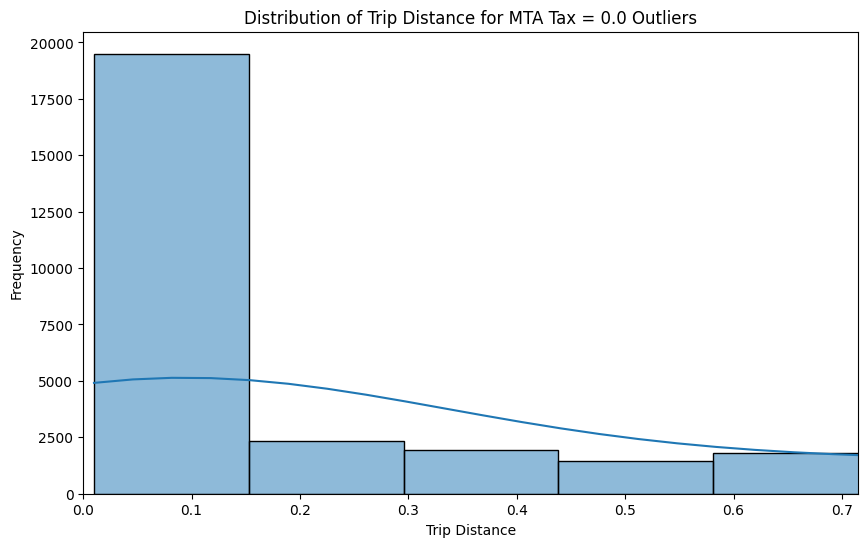

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(mta_tax_zero_trips, bins=50, kde=True)
plt.title('Distribution of Trip Distance for MTA Tax = 0.0 Outliers')
plt.xlabel('Trip Distance')
plt.ylabel('Frequency')
plt.xlim(0, mta_tax_zero_trips.max() * 0.1) # Limit x-axis to focus on smaller distances
plt.show()

Step 9: Removing `mta_tax` outliers

Removing values less than 0.5 (e.g., 0.0 and negative values):

We previously identified 0.0 as a significant outlier, accounting for 0.35% of the data. While some 0.0 values might correspond to short trips, they often represent cases where the MTA tax was not applied, or they could be data entry errors. Removing them helps us focus on trips where a standard MTA tax is expected.
We also converted negative mta_tax values to their absolute positives earlier. However, if any mta_tax values were still very small or close to zero, or still negative, they are generally considered illogical for a standard tax that is usually fixed or a minimum amount.
Removing values greater than 5:

The mta_tax overwhelmingly consists of 0.5. Any values significantly higher than this (like 10.5 or other larger values we saw) are also statistical outliers. These could represent special circumstances, errors, or different tax regimes not typical of the majority of the data. Removing them helps standardize the mta_tax column to its most common and expected range.

In [59]:
initial_rows_before_mta_tax_range_removal = df.shape[0]

# Filter out mta_tax values less than 0.5 or greater than 5
df = df[(df['mta_tax'] >= 0.5) & (df['mta_tax'] <= 5)]

print(f"Number of rows before removing mta_tax values outside [0.5, 5]: {initial_rows_before_mta_tax_range_removal}")
print(f"Number of rows after removing mta_tax values outside [0.5, 5]: {df.shape[0]}")
print(f"Number of mta_tax values outside [0.5, 5] removed: {initial_rows_before_mta_tax_range_removal - df.shape[0]}")

print("\n'mta_tax' unique values after filtering:")
print(df['mta_tax'].unique())

Number of rows before removing mta_tax values outside [0.5, 5]: 19101808
Number of rows after removing mta_tax values outside [0.5, 5]: 19079907
Number of mta_tax values outside [0.5, 5] removed: 21901

'mta_tax' unique values after filtering:
[0.5  4.75 1.   3.25 4.   3.75 4.49 4.99 2.55 1.44 1.23 2.41 2.1  4.78
 3.65 3.27 4.3  3.01 3.14 4.83 3.63 4.24 2.49 3.47 3.98 4.09 1.3  4.25
 4.4  2.44 4.7  4.76 3.39 4.57 2.73 2.97 1.03]


This column has been cleaned

### Col = tip_amount, Tip amount – This field is automatically populated for credit card tips. Cash
### tips are not included.

Step 1: Numerical column, descriptive statistics

In [60]:
df['tip_amount'].describe()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)


,tip_amount
count,1.907991e+07
mean,NaN
std,0.000000e+00
min,0.000000e+00
25%,0.000000e+00
50%,2.380859e+00
75%,3.699219e+00
max,9.610000e+02


Step 2: Checking skewness

In [61]:
# checking skewness
df['tip_amount'].skew()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)


np.float16(nan)

Step 3: Checking for outliers

In [62]:
# checking for outliers
result = detect_outliers(df, 'tip_amount')
display(df.loc[result.index, ['tip_amount', 'trip_distance', 'payment_type']])

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,tip_amount,trip_distance,payment_type
237,10.000000,5.63,1
870,12.000000,3.15,1
1248,10.000000,1.10,1
1743,20.000000,0.93,1
1911,30.031250,2.86,1
...,...,...,...
24050936,11.617188,4.60,0
24053899,30.000000,5.41,0
24058127,10.000000,2.23,0
24058708,20.000000,1.38,0


Step 4: Displaying tip_amount where payment_type is not 1(Credit Card)

In [63]:
#Display tip_amount outliers where payment_type is not 1
display(df.loc[result.index][df.loc[result.index, 'payment_type'] != 1][['tip_amount', 'trip_distance', 'payment_type']])

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,tip_amount,trip_distance,payment_type
312895,151.000000,0.94,3
443879,62.500000,0.64,4
1772029,220.000000,0.56,3
2532953,16.453125,1.32,4
2634333,20.000000,1.03,4
...,...,...,...
24050936,11.617188,4.60,0
24053899,30.000000,5.41,0
24058127,10.000000,2.23,0
24058708,20.000000,1.38,0


Step 5: Handling `tip_amount` inconsistency

The `tip_amount` should only be populated for credit card payments (`payment_type = 1`). We will set `tip_amount` to `0` for all other `payment_type` values to maintain data consistency.

In [64]:
# Set tip_amount to 0 where payment_type is not 1
initial_nonzero_tips_non_credit = df[(df['tip_amount'] != 0) & (df['payment_type'] != 1)].shape[0]
df.loc[(df['payment_type'] != 1), 'tip_amount'] = 0

print(f"Number of non-credit card tips that were non-zero before cleaning: {initial_nonzero_tips_non_credit}")
print("Tip amounts for non-credit card payment types have been set to 0.")

# Verify the change by checking for non-zero tips with non-credit card payment types
remaining_nonzero_tips_non_credit = df[(df['tip_amount'] != 0) & (df['payment_type'] != 1)].shape[0]
print(f"Number of non-zero tips with non-credit card payment types after cleaning: {remaining_nonzero_tips_non_credit}")

Number of non-credit card tips that were non-zero before cleaning: 299509
Tip amounts for non-credit card payment types have been set to 0.
Number of non-zero tips with non-credit card payment types after cleaning: 0


In [65]:
display(df.loc[result.index][df.loc[result.index, 'payment_type'] != 1][['tip_amount', 'trip_distance', 'payment_type']])

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,tip_amount,trip_distance,payment_type
312895,0.0,0.94,3
443879,0.0,0.64,4
1772029,0.0,0.56,3
2532953,0.0,1.32,4
2634333,0.0,1.03,4
...,...,...,...
24050936,0.0,4.60,0
24053899,0.0,5.41,0
24058127,0.0,2.23,0
24058708,0.0,1.38,0


In [66]:
#again checking for outliers and check if tip_amount > fare_amount
result = detect_outliers(df, 'tip_amount')

# Select the rows from the DataFrame `df` that correspond to the detected 'tip_amount' outliers
df_tip_outliers = df.loc[result.index]

# Now, from this subset, filter further to find where 'tip_amount' is greater than 'fare_amount'
illogical_tip_fare_outliers = df_tip_outliers[df_tip_outliers['tip_amount'] > df_tip_outliers['fare_amount']]

display(illogical_tip_fare_outliers[['tip_amount','fare_amount', 'trip_distance', 'payment_type']])

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,tip_amount,fare_amount,trip_distance,payment_type
1248,10.000000,8.600000,1.10,1
1743,20.000000,9.300000,0.93,1
1911,30.031250,17.000000,2.86,1
2001,10.000000,6.500000,0.60,1
4530,25.000000,15.600000,2.61,1
...,...,...,...,...
23538805,16.750000,10.000000,1.40,1
23539336,50.062500,30.299999,6.93,1
23539999,9.882812,6.500000,1.04,1
23540358,20.000000,12.100000,2.22,1


Step 6: Handling `tip_amount` > `fare_amount` inconsistencies

It is illogical for the `tip_amount` to be greater than the `fare_amount`. These are likely data entry errors or anomalies. We will identify these rows and remove them from the dataset.

In [67]:
# Identify rows where tip_amount is greater than fare_amount
illogical_tip_fare_mask = df['tip_amount'] > df['fare_amount']

# Count these rows
num_illogical_tip_fare = illogical_tip_fare_mask.sum()
print(f"Number of rows where tip_amount > fare_amount: {num_illogical_tip_fare}")

# Display some examples of these illogical entries
if num_illogical_tip_fare > 0:
    print("\nExamples of rows where tip_amount > fare_amount:")
    display(df[illogical_tip_fare_mask].head())

# Remove these illogical rows
initial_rows_before_illogical_tip_removal = df.shape[0]
df = df[~illogical_tip_fare_mask]

print(f"\nInitial number of rows: {initial_rows_before_illogical_tip_removal}")
print(f"Number of rows after removing illogical tip_amount entries: {df.shape[0]}")
print(f"Number of illogical tip_amount entries removed: {initial_rows_before_illogical_tip_removal - df.shape[0]}")

Number of rows where tip_amount > fare_amount: 19694

Examples of rows where tip_amount > fare_amount:


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1248,1,2025-02-01 00:19:26,2025-02-01 00:26:17,2.0,1.10,1.0,N,48,163,1,8.6,4.25,0.5,10.00000,0.0,1.0,24.350000,2.5,0.0,0.75
1743,2,2025-02-01 00:07:51,2025-02-01 00:17:10,4.0,0.93,1.0,N,231,148,1,9.3,1.00,0.5,20.00000,0.0,1.0,35.049999,2.5,0.0,0.75
1911,2,2025-02-01 00:25:09,2025-02-01 00:40:50,1.0,2.86,1.0,N,249,233,1,17.0,1.00,0.5,30.03125,0.0,1.0,52.779999,2.5,0.0,0.75
2001,1,2025-02-01 00:52:36,2025-02-01 00:57:39,2.0,0.60,1.0,N,114,249,1,6.5,4.25,0.5,10.00000,0.0,1.0,22.250000,2.5,0.0,0.75
3153,2,2025-02-01 00:21:02,2025-02-01 00:25:44,2.0,0.78,1.0,N,79,231,1,7.2,1.00,0.5,8.00000,0.0,1.0,20.950001,2.5,0.0,0.75



Initial number of rows: 19079907
Number of rows after removing illogical tip_amount entries: 19060213
Number of illogical tip_amount entries removed: 19694


In [68]:
# checking for outliers
result = detect_outliers(df, 'tip_amount')
display(df.loc[result.index, ['tip_amount', 'trip_distance', 'payment_type', 'fare_amount']])

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,tip_amount,trip_distance,payment_type,fare_amount
237,10.000000,5.63,1,23.299999
870,12.000000,3.15,1,15.600000
2080,10.781250,3.90,1,31.700001
2478,10.390625,4.29,1,28.900000
2800,11.226562,6.42,1,31.700001
...,...,...,...,...
23541635,10.000000,6.19,1,24.700001
23542682,10.296875,6.60,1,31.700001
23542761,10.000000,1.92,1,17.000000
23543007,10.601562,4.80,1,29.600000


In [69]:
# % of remaining outliers
pct = len(result) / df.shape[0] * 100
pct

0.32625553554936665

Step 9: Final removal of `tip_amount` outliers

Having addressed inconsistencies related to payment types and illogical `tip_amount` vs `fare_amount` ratios, I will now remove any remaining `tip_amount` outliers detected by the IQR method. This ensures that the tip data is robust and represents typical tipping behavior.

In [70]:
# Remove the remaining tip_amount outliers
initial_rows_before_final_tip_outlier_removal = df.shape[0]
df = df[~df.index.isin(result.index)]

print(f"Number of rows before removing final tip_amount outliers: {initial_rows_before_final_tip_outlier_removal}")
print(f"Number of rows after removing final tip_amount outliers: {df.shape[0]}")
print(f"Number of final tip_amount outliers removed: {initial_rows_before_final_tip_outlier_removal - df.shape[0]}")

Number of rows before removing final tip_amount outliers: 19060213
Number of rows after removing final tip_amount outliers: 18998028
Number of final tip_amount outliers removed: 62185


This column has been cleaned

### Col = tolls_amount, total amount of all tolls paid in trip.

Step 1: Numerical column, descriptive statistics

In [ ]:
df['tolls_amount'].describe()

Step 2: Checking skewness of data

In [72]:
# checking skewness
df['tolls_amount'].skew()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)


np.float16(nan)

Step 3: Detecting outliers

In [73]:
# detecting outliers
result = detect_outliers(df, 'tolls_amount')
display(df.loc[result.index, ['tolls_amount', 'trip_distance', 'payment_type']])

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,tolls_amount,trip_distance,payment_type
118,6.941406,4.50,1
121,6.941406,5.30,1
540,6.941406,2.80,1
637,6.941406,6.94,1
803,6.941406,6.42,1
...,...,...,...
24079928,6.941406,4.18,0
24080113,6.941406,4.70,0
24081216,6.941406,5.58,0
24082338,6.941406,5.20,0


Step 4: Plotting boxplot to visualise outliers

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3

<Axes: xlabel='tolls_amount'>

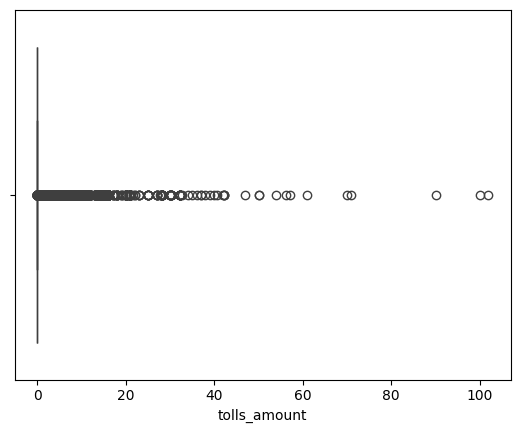

In [74]:
sns.boxplot(x = df['tolls_amount'])

Step 5: Handling `tolls_amount` outliers with Capping

Given the heavily skewed distribution of `tolls_amount` with many zero values and a few high outliers, capping is an appropriate strategy. This will replace extremely high toll amounts with an upper bound calculated using the IQR method, preserving data while mitigating the impact of outliers.

In [75]:
initial_rows_before_tolls_outlier_capping = df.shape[0]

Q1_tolls = df['tolls_amount'].quantile(0.25)
Q3_tolls = df['tolls_amount'].quantile(0.75)
IQR_tolls = Q3_tolls - Q1_tolls
upper_bound_tolls = Q3_tolls + 1.5 * IQR_tolls

# Cap outliers by replacing values above the upper bound with the upper bound itself
df.loc[df['tolls_amount'] > upper_bound_tolls, 'tolls_amount'] = upper_bound_tolls

print(f"Number of rows before capping 'tolls_amount' outliers: {initial_rows_before_tolls_outlier_capping}")
print(f"Number of 'tolls_amount' values capped: {(df['tolls_amount'] == upper_bound_tolls).sum()}")
print(f"'tolls_amount' upper bound used for capping: {upper_bound_tolls}")

Number of rows before capping 'tolls_amount' outliers: 18998028
Number of 'tolls_amount' values capped: 18998028
'tolls_amount' upper bound used for capping: 0.0


Step 7: Verifying if outliers have been capped

In [76]:
# Verify that outliers are handled by checking the number of outliers again
result_after_capping = detect_outliers(df, 'tolls_amount')
print(f"Number of 'tolls_amount' outliers after capping: {len(result_after_capping)}")


Number of 'tolls_amount' outliers after capping: 0


This column has been cleaned

### Col: `store_and_fwd_flag`

Step 1: We need to decide whether to keep or remove the `store_and_fwd_flag` column. Let's inspect its value distribution, including `NaN`s, to understand its potential utility.

In [78]:
df['store_and_fwd_flag'].value_counts(dropna=False)

,count
store_and_fwd_flag,
N,15425689
None,3515464
Y,56875


Step 2: Dropping `store_and_fwd_flag`

Given its high number of missing values and highly skewed distribution, the `store_and_fwd_flag` column will be dropped to simplify the dataset and focus on more informative features.

In [79]:
print(f"Shape of DataFrame before dropping 'store_and_fwd_flag': {df.shape}")
df.drop('store_and_fwd_flag', axis=1, inplace=True)
print(f"Shape of DataFrame after dropping 'store_and_fwd_flag': {df.shape}")

Shape of DataFrame before dropping 'store_and_fwd_flag': (18998028, 20)
Shape of DataFrame after dropping 'store_and_fwd_flag': (18998028, 19)


This column has been dropped successfully

### Col = congestion_surcharge, total amount collected in trip for NYS congestion surcharge.

Step 1: Numerical column, descriptive statistics

In [81]:
df['congestion_surcharge'].describe()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)


,congestion_surcharge
count,15482564.0
mean,NaN
std,0.0
min,0.0
25%,2.5
50%,2.5
75%,2.5
max,2.5


Step 2: Checking skewness of the data

In [82]:
# checking skewness
df['congestion_surcharge'].skew()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)


np.float16(nan)

Step 3: Checking for outliers

In [83]:
#detecting outliers
result = detect_outliers(df, 'congestion_surcharge')
display(df.loc[result.index, ['congestion_surcharge', 'trip_distance', 'payment_type']])


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,congestion_surcharge,trip_distance,payment_type
121,0.0,5.30,1
245,0.0,4.14,1
251,0.0,0.88,1
312,0.0,5.14,2
313,0.0,1.33,1
...,...,...,...
23543138,0.0,2.13,2
23543169,0.0,3.77,1
23543171,0.0,5.41,1
23543182,0.0,0.70,2


Step 4: Imputing `congestion_surcharge` null values with `0`

`0` is a valid value for `congestion_surcharge` (indicating no charge). I will now impute the `NaN` values in this column with `0`.

In [84]:
# Impute NaN values in 'congestion_surcharge' with 0
initial_nan_count_congestion = df['congestion_surcharge'].isnull().sum()
df['congestion_surcharge'].fillna(0, inplace=True)

print(f"Number of NaN values in 'congestion_surcharge' before imputation: {initial_nan_count_congestion}")
print(f"Number of NaN values in 'congestion_surcharge' after imputation: {df['congestion_surcharge'].isnull().sum()}")

/tmp/ipykernel_95314/376016934.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['congestion_surcharge'].fillna(0, inplace=True)


Number of NaN values in 'congestion_surcharge' before imputation: 3515464
Number of NaN values in 'congestion_surcharge' after imputation: 0


Step 5: Verifying the `congestion_surcharge` distribution after imputation

In [85]:
df['congestion_surcharge'].describe()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)


,congestion_surcharge
count,18998028.0
mean,NaN
std,0.0
min,0.0
25%,2.5
50%,2.5
75%,2.5
max,2.5


In [86]:
df['congestion_surcharge'].value_counts(dropna=False)

,count
congestion_surcharge,
2.50,14938773
0.00,4059252
0.75,2
1.00,1


This column has been cleaned.

#### Before moving toward Airport_fee col we need to merge the zone look up table to this dataframe.


Step 1: Importing the zone lookup table

In [91]:
zone_lookup_df = pd.read_csv('/content/drive/MyDrive/NYC dataset/taxi_zone_lookup.csv')
display(zone_lookup_df.head())

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


Step 2: Joining the zone lookup table with my main table on PULocationID

In [92]:
df = pd.merge(df, zone_lookup_df, left_on='PULocationID', right_on='LocationID', how='left')
display(df.head())

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,LocationID,Borough,Zone,service_zone
0,2,2025-02-01 00:12:18,2025-02-01 00:32:33,3.0,3.12,1.0,246,79,1,19.799999,...,0.0,1.0,30.66,2.5,0.0,0.75,246,Manhattan,West Chelsea/Hudson Yards,Yellow Zone
1,2,2025-02-01 00:40:04,2025-02-01 00:49:15,1.0,1.40,1.0,114,79,1,10.000000,...,0.0,1.0,18.90,2.5,0.0,0.75,114,Manhattan,Greenwich Village South,Yellow Zone
2,1,2025-02-01 00:06:09,2025-02-01 00:11:51,1.0,0.40,1.0,211,144,1,6.500000,...,0.0,1.0,13.25,2.5,0.0,0.75,211,Manhattan,SoHo,Yellow Zone
3,1,2025-02-01 00:15:13,2025-02-01 00:20:19,1.0,0.70,1.0,113,249,1,7.200000,...,0.0,1.0,14.95,2.5,0.0,0.75,113,Manhattan,Greenwich Village North,Yellow Zone
4,2,2025-02-01 00:02:52,2025-02-01 00:20:25,1.0,4.19,1.0,113,263,1,19.799999,...,0.0,1.0,30.66,2.5,0.0,0.75,113,Manhattan,Greenwich Village North,Yellow Zone


Step 3: Converting the full table to parquet file

In [93]:
df.to_parquet('merged_6_months_zone_lookup_yellow_taxi.parquet')

### Investigating `Airport_fee` for null value handling

Step 1: We still have null values in `Airport_fee`. Let's examine its descriptive statistics and value counts to determine the best approach for imputation or other treatment.

In [90]:
df['Airport_fee'].value_counts(dropna=False)

,count
Airport_fee,
0.00,15335370
NaN,3515464
1.75,146626
6.75,546
5.00,20
1.25,2


In [89]:
df['Airport_fee'].describe()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)


,Airport_fee
count,15482564.00
mean,NaN
std,0.00
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,6.75


Step 2: Making sure the names of the zone column has no trailing and forward spaces

In [95]:
df['Zone'].str.strip()

,Zone
0,West Chelsea/Hudson Yards
1,Greenwich Village South
2,SoHo
3,Greenwich Village North
4,Greenwich Village North
...,...
18998023,Flatiron
18998024,East Village
18998025,Little Italy/NoLiTa
18998026,Lincoln Square East


Step 3: Checking the total number of rows where airport_fees is applicable

In [99]:
# Checking the total number of rows where airport fees must be present
df['Zone'].str.contains('JFK Airport', 'LaGuardia').sum()

89456

Step 4: Only the rows where Zone = JFK Airport or LaGuardia should have airport_fees other than that each row must be imputed with 0.

In [100]:
# Identify rows where the trip is not to/from JFK Airport or LaGuardia
non_airport_zone_mask = ~df['Zone'].str.contains('JFK Airport|LaGuardia', na=False)

# Set 'Airport_fee' to 0 for these non-airport zones
initial_nonzero_non_airport_fees = df[non_airport_zone_mask & (df['Airport_fee'] != 0)].shape[0]
df.loc[non_airport_zone_mask, 'Airport_fee'] = 0

print(f"Number of non-airport zone trips with non-zero Airport_fee before correction: {initial_nonzero_non_airport_fees}")
print("Airport_fee values for non-airport zones have been set to 0.")

# Verify the distribution after this operation
print("\nAirport_fee distribution after zone-based correction:")
print(df['Airport_fee'].value_counts(dropna=False))

Number of non-airport zone trips with non-zero Airport_fee before correction: 3519650
Airport_fee values for non-airport zones have been set to 0.

Airport_fee distribution after zone-based correction:
Airport_fee
0.00    18855020
1.75      140973
NaN         1487
6.75         544
5.00           2
1.25           2
Name: count, dtype: int64


In [104]:
# Correctly identify and display rows where 'Airport_fee' is NaN
display(df[df['Airport_fee'].isnull()])

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,LocationID,Borough,Zone,service_zone
2353028,2,2025-02-01 01:01:05,2025-02-01 01:14:56,1.0,2.49,1.0,132,197,0,17.030001,...,0.0,1.0,18.530001,0.0,NaN,0.0,132,Queens,JFK Airport,Airports
2353029,2,2025-02-01 01:27:23,2025-02-01 01:42:00,1.0,5.09,1.0,132,77,0,17.590000,...,0.0,1.0,19.090000,0.0,NaN,0.0,132,Queens,JFK Airport,Airports
2353237,2,2025-02-01 01:40:44,2025-02-01 01:59:43,1.0,6.86,1.0,132,191,0,28.010000,...,0.0,1.0,29.510000,0.0,NaN,0.0,132,Queens,JFK Airport,Airports
2362332,2,2025-02-01 17:13:15,2025-02-01 17:21:35,1.0,2.92,1.0,132,76,0,11.750000,...,0.0,1.0,13.250000,0.0,NaN,0.0,132,Queens,JFK Airport,Airports
2371241,2,2025-02-01 21:53:52,2025-02-01 22:07:59,1.0,3.18,1.0,132,258,0,15.460000,...,0.0,1.0,16.959999,0.0,NaN,0.0,132,Queens,JFK Airport,Airports
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18994202,2,2025-01-31 22:55:08,2025-01-31 23:07:40,1.0,3.35,1.0,132,76,0,13.730000,...,0.0,1.0,15.230000,0.0,NaN,0.0,132,Queens,JFK Airport,Airports
18995028,2,2025-01-31 22:01:27,2025-01-31 22:10:51,1.0,2.86,1.0,132,258,0,13.320000,...,0.0,1.0,14.820000,0.0,NaN,0.0,132,Queens,JFK Airport,Airports
18995073,2,2025-01-31 22:31:08,2025-01-31 22:44:27,1.0,5.63,1.0,132,39,0,18.490000,...,0.0,1.0,19.990000,0.0,NaN,0.0,132,Queens,JFK Airport,Airports
18995456,1,2025-01-31 23:43:21,2025-01-31 23:50:39,1.0,3.10,1.0,132,219,0,11.940000,...,0.0,1.0,13.440000,0.0,NaN,0.0,132,Queens,JFK Airport,Airports


Step 5: Imputing the null fields where airport_fees is applicable with the mean of the present values

In [105]:
jfk_airport_fee_mean = df[df['Zone'] == 'JFK Airport']['Airport_fee'].mean()
print(f"Mean Airport_fee for JFK Airport: {jfk_airport_fee_mean:.2f}")

Mean Airport_fee for JFK Airport: nan


/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan


In [106]:
laguardia_airport_fee_mean = df[df['Zone'] == 'LaGuardia']['Airport_fee'].mean()
print(f"Mean Airport_fee for LaGuardia: {laguardia_airport_fee_mean:.2f}")

Mean Airport_fee for LaGuardia: nan


Step 5: After imputing bringing up the statistics

In [107]:
# Get non-zero Airport_fee values for JFK Airport and LaGuardia
airport_zones_fees = df[df['Zone'].isin(['JFK Airport', 'LaGuardia']) & (df['Airport_fee'].notna()) & (df['Airport_fee'] > 0)]['Airport_fee']

if not airport_zones_fees.empty:
    # Calculate the mode of these non-zero fees
    airport_fee_mode = airport_zones_fees.mode()[0]
    print(f"Mode of non-zero Airport_fee for JFK/LaGuardia zones: {airport_fee_mode:.2f}")

    # Impute the remaining NaN Airport_fee values (which are confirmed to be in JFK Airport zone) with this mode
    initial_nan_airport_fee = df['Airport_fee'].isnull().sum()
    df.loc[df['Airport_fee'].isnull(), 'Airport_fee'] = airport_fee_mode

    print(f"Number of NaN values in 'Airport_fee' before imputation: {initial_nan_airport_fee}")
    print(f"Number of NaN values in 'Airport_fee' after imputation: {df['Airport_fee'].isnull().sum()}")
    print(f"Remaining NaN values for Airport_fee have been imputed with {airport_fee_mode:.2f}.")
else:
    print("No non-zero Airport_fee values found for JFK Airport or LaGuardia zones to determine a mode for imputation. Consider an alternative imputation strategy if needed.")

Mode of non-zero Airport_fee for JFK/LaGuardia zones: 1.75
Number of NaN values in 'Airport_fee' before imputation: 1487
Number of NaN values in 'Airport_fee' after imputation: 0
Remaining NaN values for Airport_fee have been imputed with 1.75.


Step 6: Verifying the distribution after imputation

In [108]:
# Verify the distribution after imputation
print("\nAirport_fee distribution after final imputation:")
print(df['Airport_fee'].value_counts(dropna=False))


Airport_fee distribution after final imputation:
Airport_fee
0.00    18855020
1.75      142460
6.75         544
5.00           2
1.25           2
Name: count, dtype: int64


### Col = Borough, since the the null values in this col is very less we can drop those rows containing null values

Step 1: Dropping rows where borough is null

In [110]:
# Drop rows where 'Borough' is null
initial_rows_before_borough_null_removal = df.shape[0]
df.dropna(subset=['Borough'], inplace=True)

print(f"Number of rows before removing null 'Borough' values: {initial_rows_before_borough_null_removal}")
print(f"Number of rows after removing null 'Borough' values: {df.shape[0]}")
print(f"Number of null 'Borough' values removed: {initial_rows_before_borough_null_removal - df.shape[0]}")

# Verify that there are no more null values in 'Borough'
print("\nNull values in 'Borough' after cleaning:")
print(df['Borough'].isnull().sum())

Number of rows before removing null 'Borough' values: 18998028
Number of rows after removing null 'Borough' values: 18997572
Number of null 'Borough' values removed: 456

Null values in 'Borough' after cleaning:
0


Step 2: I will be dropping the null valued rows for zone as well since it is a categorical column imputing null values with mode will make the dataset problematic

In [111]:
# Drop rows where 'Zone' is null
initial_rows_before_zone_null_removal = df.shape[0]
df.dropna(subset=['Zone'], inplace=True)

print(f"Number of rows before removing null 'Zone' values: {initial_rows_before_zone_null_removal}")
print(f"Number of rows after removing null 'Zone' values: {df.shape[0]}")
print(f"Number of null 'Zone' values removed: {initial_rows_before_zone_null_removal - df.shape[0]}")

# Verify that there are no more null values in 'Zone'
print("\nNull values in 'Zone' after cleaning:")
print(df['Zone'].isnull().sum())

Number of rows before removing null 'Zone' values: 18997572
Number of rows after removing null 'Zone' values: 18964310
Number of null 'Zone' values removed: 33262

Null values in 'Zone' after cleaning:
0


Step 3: I will be dropping the null valued rows for service_zone as well since it is a categorical column imputing null values with mode will make the dataset problematic

In [112]:
# Drop rows where 'service_zone' is null
initial_rows_before_service_zone_null_removal = df.shape[0]
df.dropna(subset=['service_zone'], inplace=True)

print(f"Number of rows before removing null 'service_zone' values: {initial_rows_before_service_zone_null_removal}")
print(f"Number of rows after removing null 'service_zone' values: {df.shape[0]}")
print(f"Number of null 'service_zone' values removed: {initial_rows_before_service_zone_null_removal - df.shape[0]}")

# Verify that there are no more null values in 'service_zone'
print("\nNull values in 'service_zone' after cleaning:")
print(df['service_zone'].isnull().sum())

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


Number of rows before removing null 'service_zone' values: 18964310
Number of rows after removing null 'service_zone' values: 18964310
Number of null 'service_zone' values removed: 0

Null values in 'service_zone' after cleaning:
0


### col = cbd_congestion_fee

Step 1: Numerical column, descriptive statistics

In [113]:
df['cbd_congestion_fee'].describe()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)


,cbd_congestion_fee
count,18964310.00
mean,NaN
std,0.00
min,0.00
25%,0.00
50%,0.75
75%,0.75
max,1.50


Step 2: Checking the value counts of this column

In [115]:
df['cbd_congestion_fee'].value_counts()

,count
cbd_congestion_fee,
0.75,14203844
0.00,4760365
1.25,97
1.50,4


Step 3: Detecting outliers

In [117]:
# detecting outliers
result = detect_outliers(df, 'cbd_congestion_fee')
display(df.loc[result.index, ['cbd_congestion_fee', 'trip_distance', 'payment_type']])

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,cbd_congestion_fee,trip_distance,payment_type


This column is cleaned

### Col = improvement_surcharge, Improvement surcharge assessed trips at the flag drop. The improvement
### surcharge began being levied in 2015.

Step 1: Numerical column, descriptive statistics

In [118]:
df['improvement_surcharge'].describe()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)


,improvement_surcharge
count,18964310.0
mean,NaN
std,0.0
min,0.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


Step 2: Checking for value counts

In [120]:
df['improvement_surcharge'].value_counts()

,count
improvement_surcharge,
1.000000,18857444
0.000000,105273
0.300049,1593


Step 3: Detecting outliers

In [119]:
# detecting outliers
result = detect_outliers(df, 'improvement_surcharge')
display(df.loc[result.index, ['improvement_surcharge', 'trip_distance', 'payment_type']])

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,improvement_surcharge,trip_distance,payment_type
11634,0.000000,1.30,1
12295,0.000000,6.80,1
12311,0.000000,6.60,1
12844,0.000000,6.20,1
13065,0.000000,6.00,1
...,...,...,...
18970725,0.300049,1.72,0
18983209,0.300049,6.24,0
18984580,0.300049,1.03,0
18984581,0.300049,0.42,0


Step 4: Handling `improvement_surcharge` outliers

The `improvement_surcharge` is typically a fixed amount (mostly `1.0`) or `0.0` when not applied. The value `0.300049` is an illogical fractional amount that represents an outlier. I will remove these specific rows to ensure the integrity of the surcharge data.

In [121]:
initial_rows_before_improvement_surcharge_removal = df.shape[0]

# Remove rows where 'improvement_surcharge' is 0.300049
# As this value is detected as an outlier and is an illogical fractional amount for a surcharge.
df = df[df['improvement_surcharge'] != 0.300049]

print(f"Number of rows before removing improvement_surcharge outliers: {initial_rows_before_improvement_surcharge_removal}")
print(f"Number of rows after removing improvement_surcharge outliers: {df.shape[0]}")
print(f"Number of improvement_surcharge outliers removed: {initial_rows_before_improvement_surcharge_removal - df.shape[0]}")

# Verify the remaining unique values
print("\n'improvement_surcharge' unique values after cleaning:")
print(df['improvement_surcharge'].value_counts(dropna=False))

Number of rows before removing improvement_surcharge outliers: 18964310
Number of rows after removing improvement_surcharge outliers: 18962717
Number of improvement_surcharge outliers removed: 1593

'improvement_surcharge' unique values after cleaning:
improvement_surcharge
1.0    18857444
0.0      105273
Name: count, dtype: int64


This column has been cleaned

### Col = total_amount, The total amount charged to passengers. Does not include cash tips.

Step 1: Calculating total_amount by using formula

In [ ]:
df['calculated_total_amount'] = df['fare_amount'] + df['extra'] + df['mta_tax'] + \
                                df['tip_amount'] + df['tolls_amount'] + df['improvement_surcharge'] + \
                                df['congestion_surcharge'] + df['Airport_fee'] + df['cbd_congestion_fee']

discrepancy = (df['total_amount'] - df['calculated_total_amount']).abs()

# Identify rows with significant discrepancies (e.g., greater than a small epsilon)
discrepancy_threshold = 0.01 # Define a small threshold for floating point comparison
discrepant_rows = df[discrepancy > discrepancy_threshold]

Step 2: Since the `total_amount` column is directly derived from other columns, it's highly susceptible to inconsistencies if the sum does not match. Therefore, we will replace the existing `total_amount` column with our `calculated_total_amount` to ensure accuracy. Then, we will remove the `calculated_total_amount` temporary column.

In [ ]:
# Replace the original 'total_amount' with the calculated one
df['total_amount'] = df['calculated_total_amount']

# Drop the temporary 'calculated_total_amount' column
df.drop(columns=['calculated_total_amount'], inplace=True)

print("Original 'total_amount' column has been replaced with the calculated values.")

In [7]:
df.head()

NameError: name 'df' is not defined

# Next we will convert the whole cleaned df to parquet

In [ ]:
df.to_parquet('cleaned_yellow_taxi_2025.parquet')